# **CalSim II Model Output Points — Building a Skill from a CKAN Dataset**

The [CalSim II OutputData](https://data.cnra.ca.gov/dataset/i12-calsimii-outputdata1)
dataset (California Natural Resources Agency open-data portal,
published by the CA Department of Water Resources) records the
**45 spatial reference points** where the CalSim II planning model
reports its outputs — one point per channel-flow node, reservoir
outflow, or diversion arc in California's Central Valley Project /
State Water Project system. CalSim II is the official planning
model used to simulate SWP/CVP operations across water years
1922–2003 (plus early- and late-century climate-change scenarios);
its output geometry is the reference set every subsequent
simulation results table can be joined on.

The dataset is packaged as a CKAN resource bundle: a CSV of point
attributes with `X`/`Y` coordinates, a Shapefile ZIP, and a native
GeoJSON — three parallel encodings of the same 45 points. The
`%%skill-build` cell below runs a **two-skill chain**: ARGUS's
`ckan-skill-builder` first downloads the tabular resources into a
local scratch directory (skipping non-tabular items like the KML
and the ArcGIS-Hub landing page), then hands off to
`tabular-skill-builder` for the enumerate → propose → build
pipeline. The `%%ask` reply in the next cell confirms the plan and
kicks off the build.


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 13 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

In [3]:
%%skill-build
https://data.cnra.ca.gov/api/3/action/package_show?id=i12-calsimii-outputdata1.

The URL is a CKAN dataset API endpoint (`/api/3/action/package_show?id=...`) on `data.cnra.ca.gov`. This matches the `ckan-skill-builder` meta-skill, which explicitly lists `data.cnra.ca.gov` as a supported CKAN portal. Let me read its instructions.

This is a CKAN dataset URL on `data.cnra.ca.gov`, so the `ckan-skill-builder` meta-skill applies. It's a fetcher that downloads tabular resources, then hands off to `tabular-skill-builder` (which has a two-phase workflow: enumerate → propose → STOP for approval → build).

Let me set up my task list and start the fetch.

The skill bundles a `fetch.py`. Let me verify its location and the tabular-skill-builder path before running.

Both scripts exist. Running the bundled `fetch.py` to download the dataset's tabular resources into the scratch directory.

Running fetch.py without the timeout override.

Fetch succeeded: 3 tabular resources downloaded (CSV, a Shapefile ZIP unpacked to 5 files, and a GeoJSON); 3 resources skipped. Now I follow the handoff — reading the `tabular-skill-builder` SKILL.md and the CKAN metadata in full, and listing the download directory.

Now I'll run the bundled `inventory.py` on the download directory — this is my first picture of the data, per the pre-flight rules.

The inventory is clear. Let me check the skipped resources (an allowed `_`-prefixed metadata sidecar) so I can accurately report what wasn't downloaded.

The picture is complete. This is a **spatial** dataset (a point feature class with 45 CalSim II output locations). Let me update my progress, then write the proposal and stop at the Step 4 gate.

I've inspected the download directory. Here's what I found and what I propose.

**Source:** `https://data.cnra.ca.gov/dataset/i12-calsimii-outputdata1` (California Department of Water Resources, "i12 CalSIMII OutputData", CC-BY license)

**Files scanned:** 3 data files — 1 CSV, 1 Shapefile, 1 GeoJSON (45 rows each). All three represent the **same 45 CalSim II output point locations** . 3 additional resources were skipped during fetch (ArcGIS Hub HTML page, ArcGIS MapServer REST API, and a KML export — none tabular-queryable).

**Inventory summary:**
- **Group A** (Shapefile + GeoJSON, native geometry, 11 attribute columns): the point feature class.
- **Group B** (CSV, 12 columns = same 11 attributes + `X`/`Y` coordinate columns instead of native geometry): the same 45 points.

---

**Proposed skill:**

1. **`calsim-ii-output-locations`** (spatial)
   - **Entity:** each row is a CalSim II model output location (a point in California's Central Valley) with its metadata — `PointID`, `PointName`, `CalSimArc`, `DataType`, `DataSource`, `Comments`, `EditedDate`, etc. These are the 44–45 reference locations used in the 2016 WSIP climate-change study, with simulations spanning 1921–2003 across early-century (2030) and late-century (2070) climate projections.
   - **Merged from:** the Shapefile (`i12_CalSIMII_OutputData.shp`) and GeoJSON as the authoritative geometry source (native CRS, ~45 point features); the CSV is the same data with `X`/`Y` columns and will be reconciled/verified against it.
   - **Estimated rows:** 45 point features
   - **Output:** `data/calsim-ii-output-locations.gpkg` (GeoPackage, since this is a spatial dataset)
   - **Key columns:** `PointID`, `PointName`, `CalSimArc`, `DataType`, `DataSource`, geometry (point)

**Open question (one):** The CSV (Group B) is a near-match to the Shapefile/GeoJSON (Group A) — same 45 locations, differing only by storing coordinates as `X`/`Y` columns instead of a native geometry. I propose **merging all three into the single spatial skill above** , using the Shapefile as the geometry source. The dataset's catalog description also mentions a "related table of timeseries data," but that resource is only exposed via the ArcGIS MapServer REST API (which was skipped as non-tabular) and is **not** present in the downloadable files — so this skill will cover the point locations only, not the timeseries.

Reply with **"yes"** to proceed as proposed, or with edits (e.g., rename the skill, keep the CSV as a separate tabular skill, etc.).

(Resume state on disk: `/tmp/repo-skills/i12-calsimii-outputdata1/` — the source files and `_inventory.json` are both there.)

In [4]:
%%ask
Yes, please create this skill.

I'll read the tabular-skill-builder instructions to follow the build workflow precisely.

The user approved, so I'll read the rest of the build workflow (Steps 6-9) before writing the build script.

I've re-read the build workflow. Let me reorient by confirming the source files and inventory are still present.

Good — source files and `_inventory.json` are present. Let me read the inventory and CKAN metadata sidecar to inform the build script.

Let me see the CSV group details from the inventory.

...

Running the build script.

Build succeeded cleanly — 45 points, unique IDs, coordinates in California range (2 points fall west of my conservative sanity box, which is expected since the dataset spans the full Central Valley/Sacramento Valley). Now writing the SKILL.md.

Now verifying the skill outputs exist and cleaning up scratch files + source directory.

Both outputs exist and the GPKG reads back cleanly (45 rows, 11 cols, EPSG:4326). Now removing the scratch probe file and the source directory per the mandatory cleanup step.

✓ Built skill **calsim-ii-output-locations** at `_skills_/calsim-ii-output-locations/SKILL.md`.

Each row is a CalSim II model output location — a point on a California Central Valley reservoir, river, canal, or Delta channel where DWR's CalSim II water-resources model reports simulated flow (45 point features, spanning the Sacramento and San Joaquin watersheds, built from the 2016 WSIP climate-change study).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Output type | `DataType` | `RESERVOIR-OUTFLOW`, `CHANNEL-FLOW`, `DIVERSION` |
| Model arc ID | `CalSimArc` | `C18`, `C52`, `D166A`, `D18B`, `C603` |
| Location name | `PointName` | "Shasta Lake Outflow", "Delta Outflow", "Sacramento River at Freeport", "San Joaquin River at Vernalis" |
| River / facility | `PointName` (text search) | "Sacramento", "San Joaquin", "Feather", "American", "Delta" |
| Model point number | `PointID` | 1, 2, 3, … 45 (unique) |
| Provenance | `DataSource` | `CH2M` (constant — compiled for the 2016 WSIP study) |
| Spatial area | `geometry` | any rectangle in WGS84, lon [-122.79°, -119.68°] / lat [36.78°, 40.73°] |

**Example queries:**

- **By output type** — "show me all the reservoir outflow points"
- **By output type** — "how many channel-flow points are there versus diversions?"
- **By river** — "all CalSim points on the Sacramento River"
- **By river** — "compare the number of output points on the Sacramento vs. the San Joaquin"
- **By name** — "where is the Delta Outflow node?"
- **By spatial area** — "CalSim II points within the Sacramento–San Joaquin Delta"
- **Combined** — "reservoir outflows north of 39° latitude" (northern Sacramento Valley reservoirs)

The skill returns a **GeoDataFrame** (Point geometry, EPSG:4326) you can spatially join or overlay with other Central Valley data.

**Caveat:** This skill holds the 45 point locations and their metadata only. The associated CalSim II timeseries (1922–2003 simulated flows under early-century 2030 and late-century 2070 climate scenarios, including the DEW/WMW variants) are hosted separately on the ArcGIS MapServer and were not included in the downloadable resources — they are not queryable through this skill.

#### **The whole CalSim II output network on one map — Orientation**

I'll read the skill to understand the data location and schema, then build the map.

Let me read the rest of the skill file and check the data directory.

The skill data is clear: 45 points across 3 DataType categories. Now I'll write a script to export the GeoJSON with a colormap, and produce a companion bar chart of counts by type.

Running the script to generate the map and chart.

The map, colormap, and chart generated successfully. Let me get finer-grained spatial detail to support the clustering commentary, focusing on the Delta confluence area.

Let me fix the spatial distribution analysis to support the clustering commentary.

I now have the full spatial picture. Here's the map and analysis.


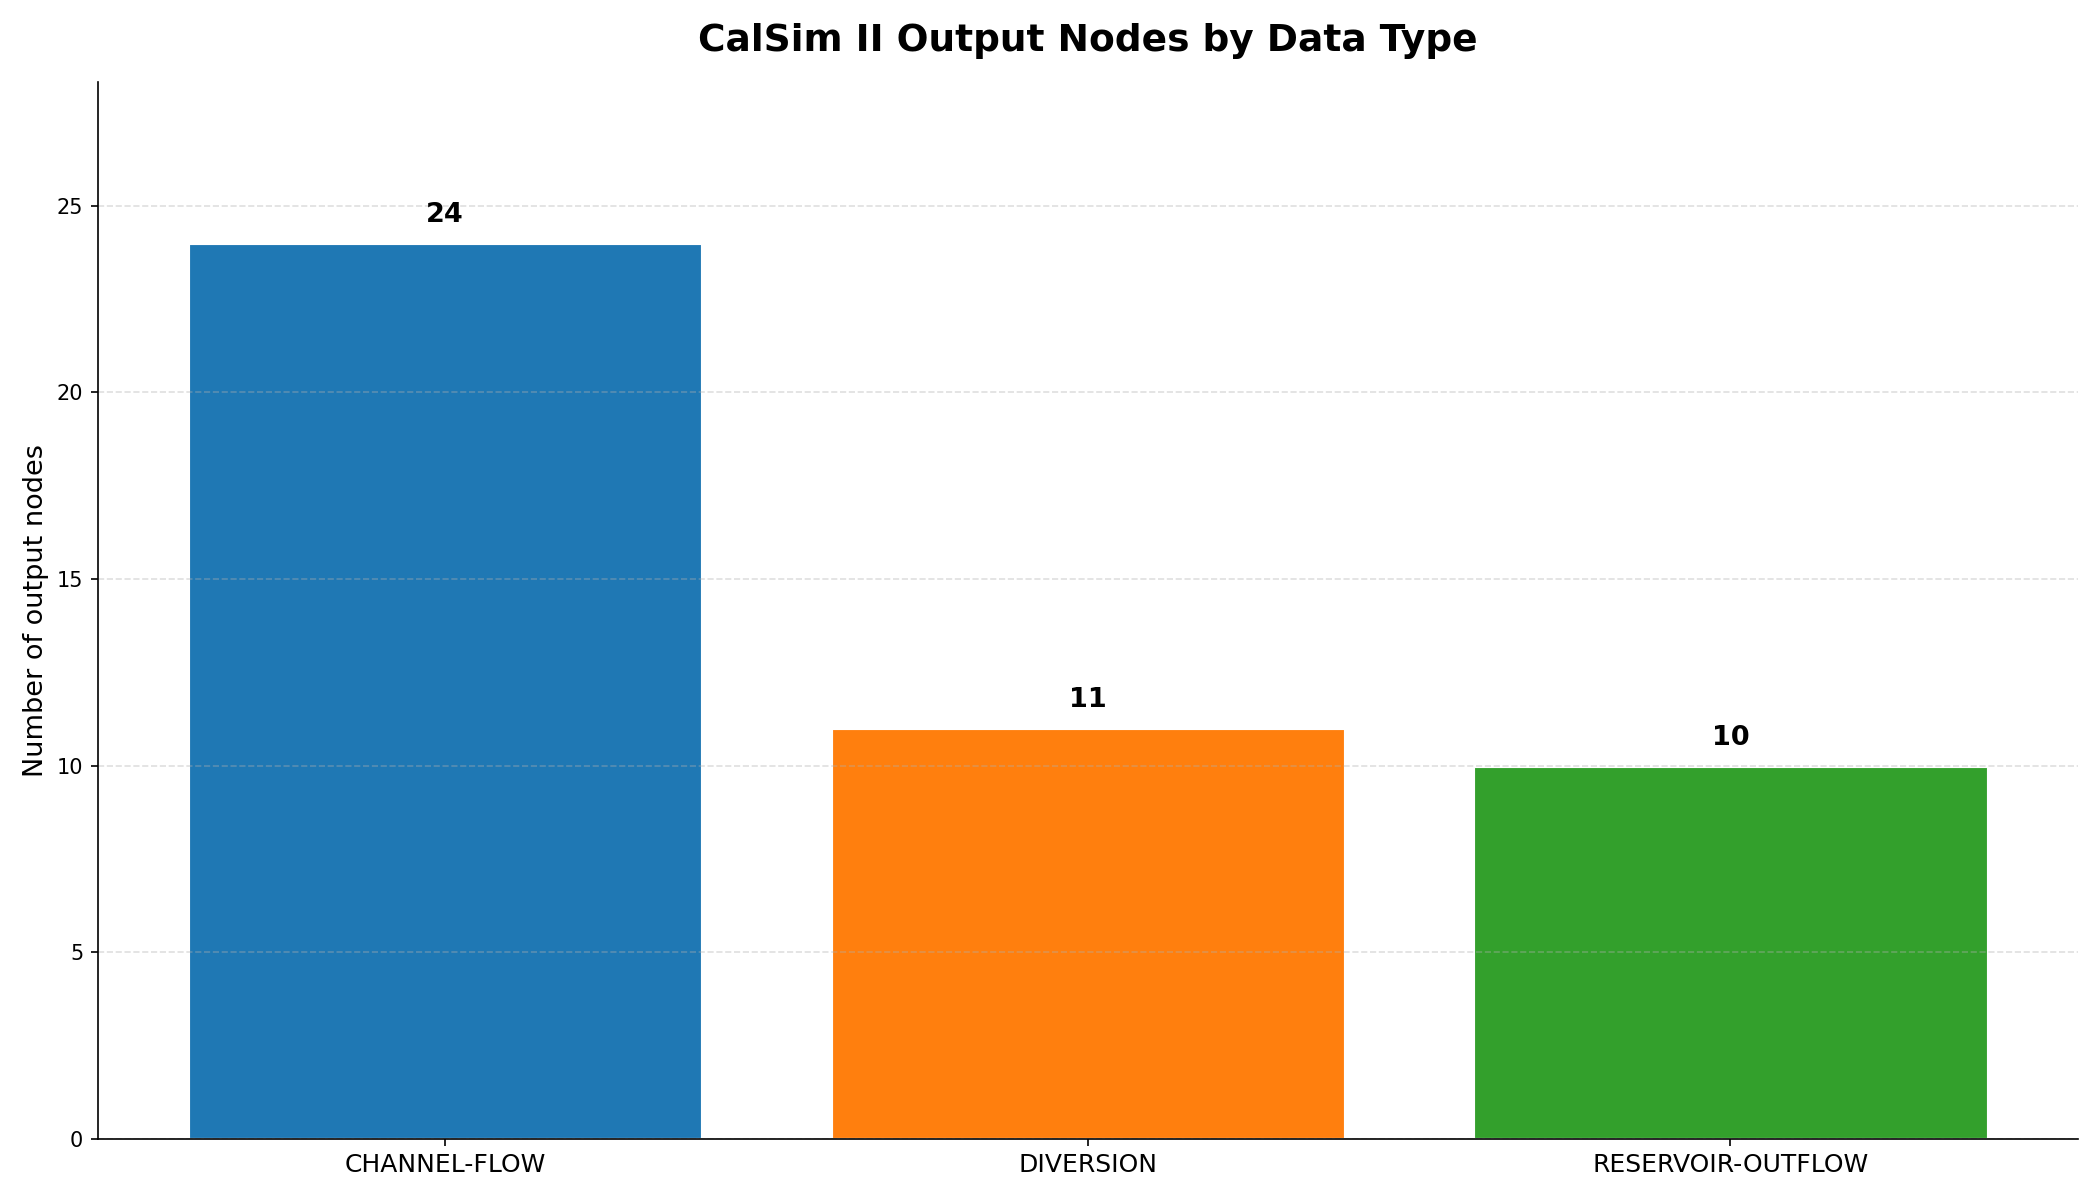

## All 45 CalSim II Output Points

The 45 nodes break into three output types: **24 channel-flow** (53%), **11 diversion** (24%), and **10 reservoir-outflow** (22%) points. They span the full Central Valley from Shasta Lake in the north (~40.7°) to the Mendota Pool / Friant-Kern Canal in the south (~36.8°).

## Where the nodes cluster

The densest single cluster sits in the **northern Sacramento Valley** (north of 39° latitude), with **14 of the 45 points** (31%). This cluster is driven by two things:

- **Rim reservoirs** — Shasta Lake, Lake Oroville, Lewiston Lake, and Black Butte Reservoir all report reservoir-outflow here, along with channel-flow points immediately downstream (Sacramento River below Keswick Dam, Feather River below Thermalito Diversion Dam, Sacramento River at Red Bluff).
- **Sutter Bypass diversions** — a run of five diversion nodes (Tisdale, Colusa, and Moulton weirs, plus the Sacramento River spill and Glenn-Colusa Canal) all tap the Sacramento River in this reach.

A **secondary cluster of 9 points** concentrates around the **Sacramento metro confluence area** (38.5°–39.0°), where the American, Feather, and Sacramento rivers come together. This is dominated by channel-flow nodes (American River below Nimbus Dam, Sacramento River at Verona, Knights Landing, Wilkins Slough) plus Sacramento Weir diversion nodes.

To the **south, the San Joaquin Valley** (below 37.5°) holds **10 points** — its own self-contained cluster anchored by Millerton, Hensley, and Eastman lake outflows and the San Joaquin River channel downstream to Mendota, with the Friant-Kern Canal diversions.

The **Sacramento–San Joaquin Delta** itself, by contrast, is comparatively sparse — only a handful of channel-flow nodes (Sacramento River at Freeport, San Joaquin River at Vernalis, plus the Calaveras and Stanislaus inflow points) sit in the confluence corridor. The model's monitoring density is clearly weighted toward the upstream reservoirs and the major-river conveyance reaches rather than the Delta interior.

**Bottom line:** the northern Sacramento Valley is the single densest cluster of CalSim II output nodes, reflecting the concentration of the state's largest reservoirs and the Sacramento River's bypass diversion network there.

In [5]:
%%ask
Show all 45 CalSim II output points on a California-centered map, color-coded by
data type — one color each for channel-flow, reservoir-outflow, and diversion nodes.
Comment on which parts of the Central Valley carry the densest cluster of output nodes.

#### **Which California counties host the most model output nodes? — County-level footprint**

I'll spatially join the CalSim II points against California county boundaries to count points per county, then build a choropleth. Let me consult the needed skills first.

Both skills are clear. I'll load CA county boundaries from the Census TIGER source, load the CalSim II points from the cached GeoPackage, spatial-join them, and build a choropleth. Let me locate the GeoPackage first.

Found the GeoPackage. Now I'll write the analysis script — load CA counties, spatial-join against CalSim points, count per county, and build the choropleth map.

I have a stray `#` typo in the colormap dict that will break the script. Fixing it before running.

Now running the analysis script.

All 45 points assigned to counties with zero unassigned. Let me verify the output files and the points layer from the prior cell exist before assembling the map.

All outputs verified. Here are the results.

## Top 8 California counties by CalSim II output points

| Rank | County | Points |
|---|---|---|
| 1 | **Yolo** | 5 |
| 1 | **Fresno** | 5 |
| 3 | Tehama | 3 |
| 3 | Butte | 3 |
| 3 | San Joaquin | 3 |
| 3 | Colusa | 3 |
| 3 | Stanislaus | 3 |
| 3 | Sutter | 3 |

All 45 points landed cleanly inside county boundaries (zero unassigned). Note the long tie at 3 points — ranks 3 through 10 are knotted, so the "top 8" cutoff falls in the middle of a plateau. The two genuine leaders are **Yolo (5)** and **Fresno (5)** .


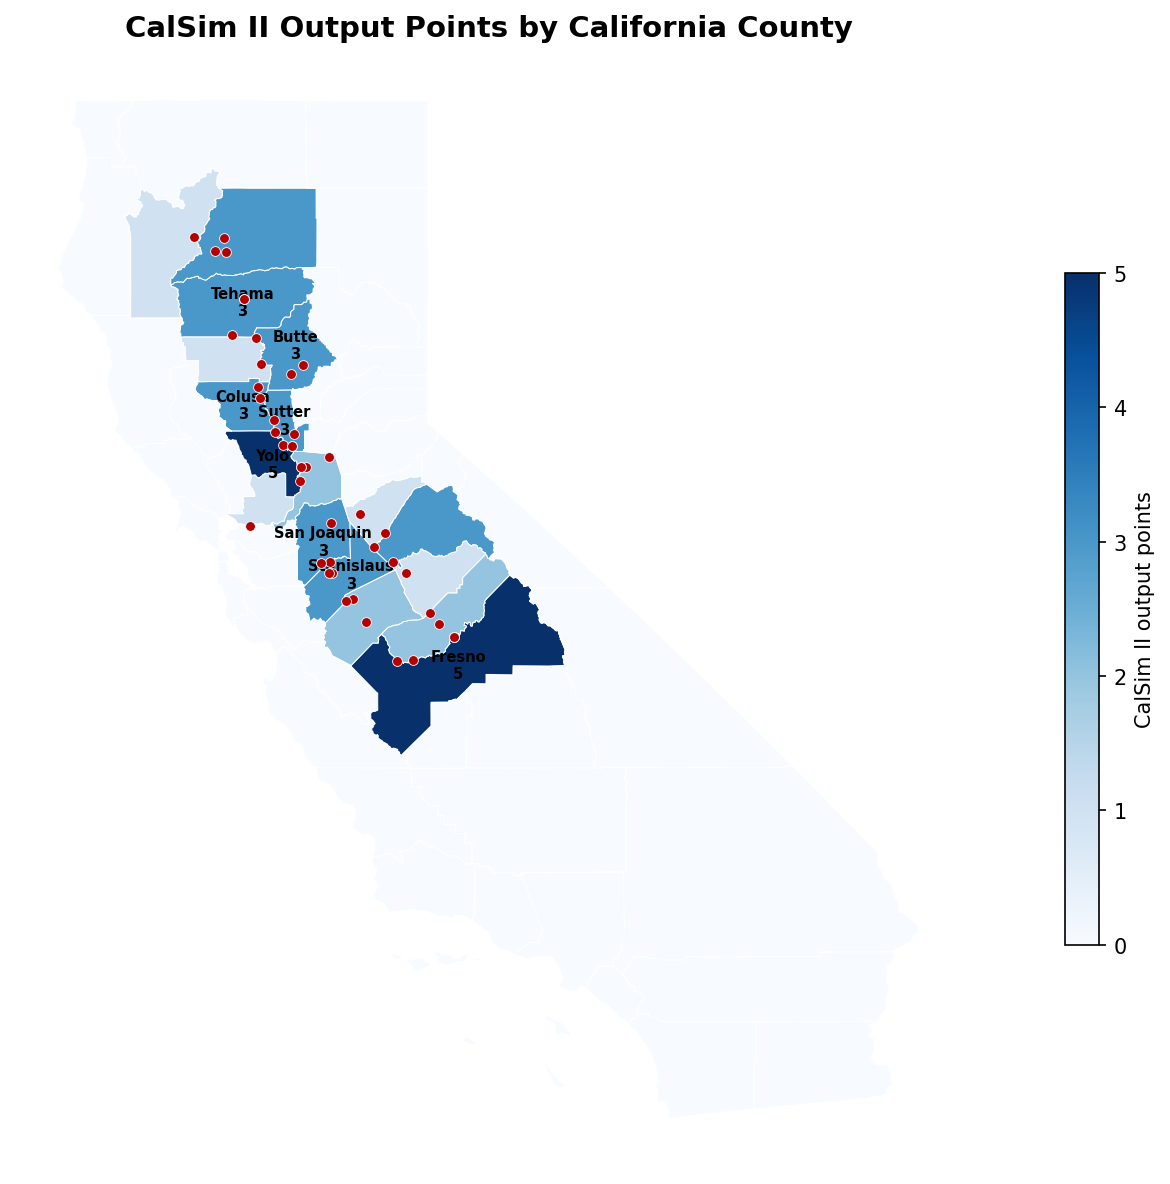

## Which counties dominate the water-infrastructure footprint

**No single county dominates — the footprint is deliberately spread across two distinct hubs, one per valley.**

**Yolo County (5 pts)** leads for the Sacramento Valley. It sits at the critical Sacramento River / Yolo Bypass corridor just upstream of the Delta, collecting the bypass-and-weir diversion nodes (Sacramento Weir Spills, Knights Landing, Wilkins Slough) that route Sacramento floodwater into the bypass. It's a *conveyance* hub — the points here are about moving and spilling water, not storing it.

**Fresno County (5 pts)** leads for the San Joaquin Valley. It anchors the Friant system: Millerton Lake / Friant Dam outflow, the Mendota Pool, the San Joaquin River channel below Friant, and the Friant-Kern and Madera canal diversions. This is the *supply* hub for the federal Central Valley Project on the east side of the valley.

**The cluster at 3 points each tells the structural story.** The Sacramento River reservoir-and-river corridor — Shasta, Tehama, Butte, Colusa, Sutter — each holds 3 nodes, tracing the mainstem Sacramento from Shasta Dam down to the Sutter Bypass. On the San Joaquin side, Stanislaus and San Joaquin counties each hold 3. The Sierra-foothill storage counties (Tuolumne for New Melones/Don Pedro, Calaveras for New Hogan) appear with 3 and 1 respectively.

**Counties with zero CalSim nodes** are conspicuous: the heavily populated Bay Area (Alameda, Santa Clara, Contra Costa) and South Coast (Los Angeles, San Diego, Orange) have none, confirming the model's scope is strictly the Central Valley watershed and its rim reservoirs — not the coastal or urban demand centers that actually receive the water.

**Bottom line:** the state's modeled water-infrastructure footprint is *bipolar* — a Sacramento-side cluster centered on Yolo (conveyance) and Shasta/Tehama/Butte (storage + river), and a San Joaquin-side cluster centered on Fresno (Friant supply) and Stanislaus/San Joaquin. Yolo and Fresno are the two counties that carry the densest monitoring of how water moves through California's engineered plumbing.

In [6]:
%%ask
Which California counties contain the most CalSim II output points?
List the top 8, and show the pattern on a map of California with each
county shaded darker if it holds more points. Comment on which counties
dominate the state's water-infrastructure footprint.

#### **From reservoir release to nearest diversion — Downstream distance analysis**

I'll work through this systematically. Let me start by checking the skill structure and the data.

Let me read the skill and the established color registry to reuse conventions correctly.

Let me read the rest of the SKILL.md and the data directory.

I have everything I need. Let me set up a plan and write the analysis script.

Now I'll write the analysis script. It computes nearest-neighbor distances in a metric CRS, builds connection lines, and produces both the map data and a bar chart.

The script ran clean. Let me retrieve the printed results from stdout.

All 10 pairs computed. Now let me verify the output files exist and update the todo list.

Let me add colormap sidecars for the point subsets so they render in the established DataType colors (green reservoirs, orange diversions).

All outputs ready. Here's the analysis.

## The 10 reservoir → nearest-diversion pairings

For each of the 10 reservoir-outflow nodes, the table below gives its closest CalSim II diversion point and the straight-line distance (computed in NAD83 / California Albers, EPSG:3310, an accurate planar metric CRS for the state).

| # | Reservoir-outflow node | Nearest diversion node | Dist. (km) |
|---|---|---|---:|
| 1 | Millerton Lake Outflow | Friant-Kern Canal Diversion | **0.0** |
| 2 | Hensley Lake Outflow | Friant-Kern Canal Diversion | 21.5 |
| 3 | Eastman Lake Outflow | Friant-Kern Canal Diversion | 35.5 |
| 4 | Lake McClure Outflow | Friant-Kern Canal Diversion | 83.9 |
| 5 | New Don Pedro Reservoir Outflow | Friant-Kern Canal Diversion | 101.3 |
| 6 | New Melones Reservoir Outflow | Sacramento Weir Spills | 111.3 |
| 7 | New Hogan Reservoir Outflow | Sacramento Weir Spills | 78.5 |
| 8 | Lake Oroville Outflow | Sacramento River Spill to Sutter Bypass | 43.1 |
| 9 | Shasta Lake Outflow | Sacramento River at Red Bluff | 65.9 |
| 10 | Black Butte Outflow | Glenn Colusa Canal | 25.4 |

Distances range from **0.0 km** (Millerton → Friant-Kern Canal, co-located at Friant Dam) to **111 km** (New Melones → Sacramento Weir Spills), with a **median of 54.5 km** .


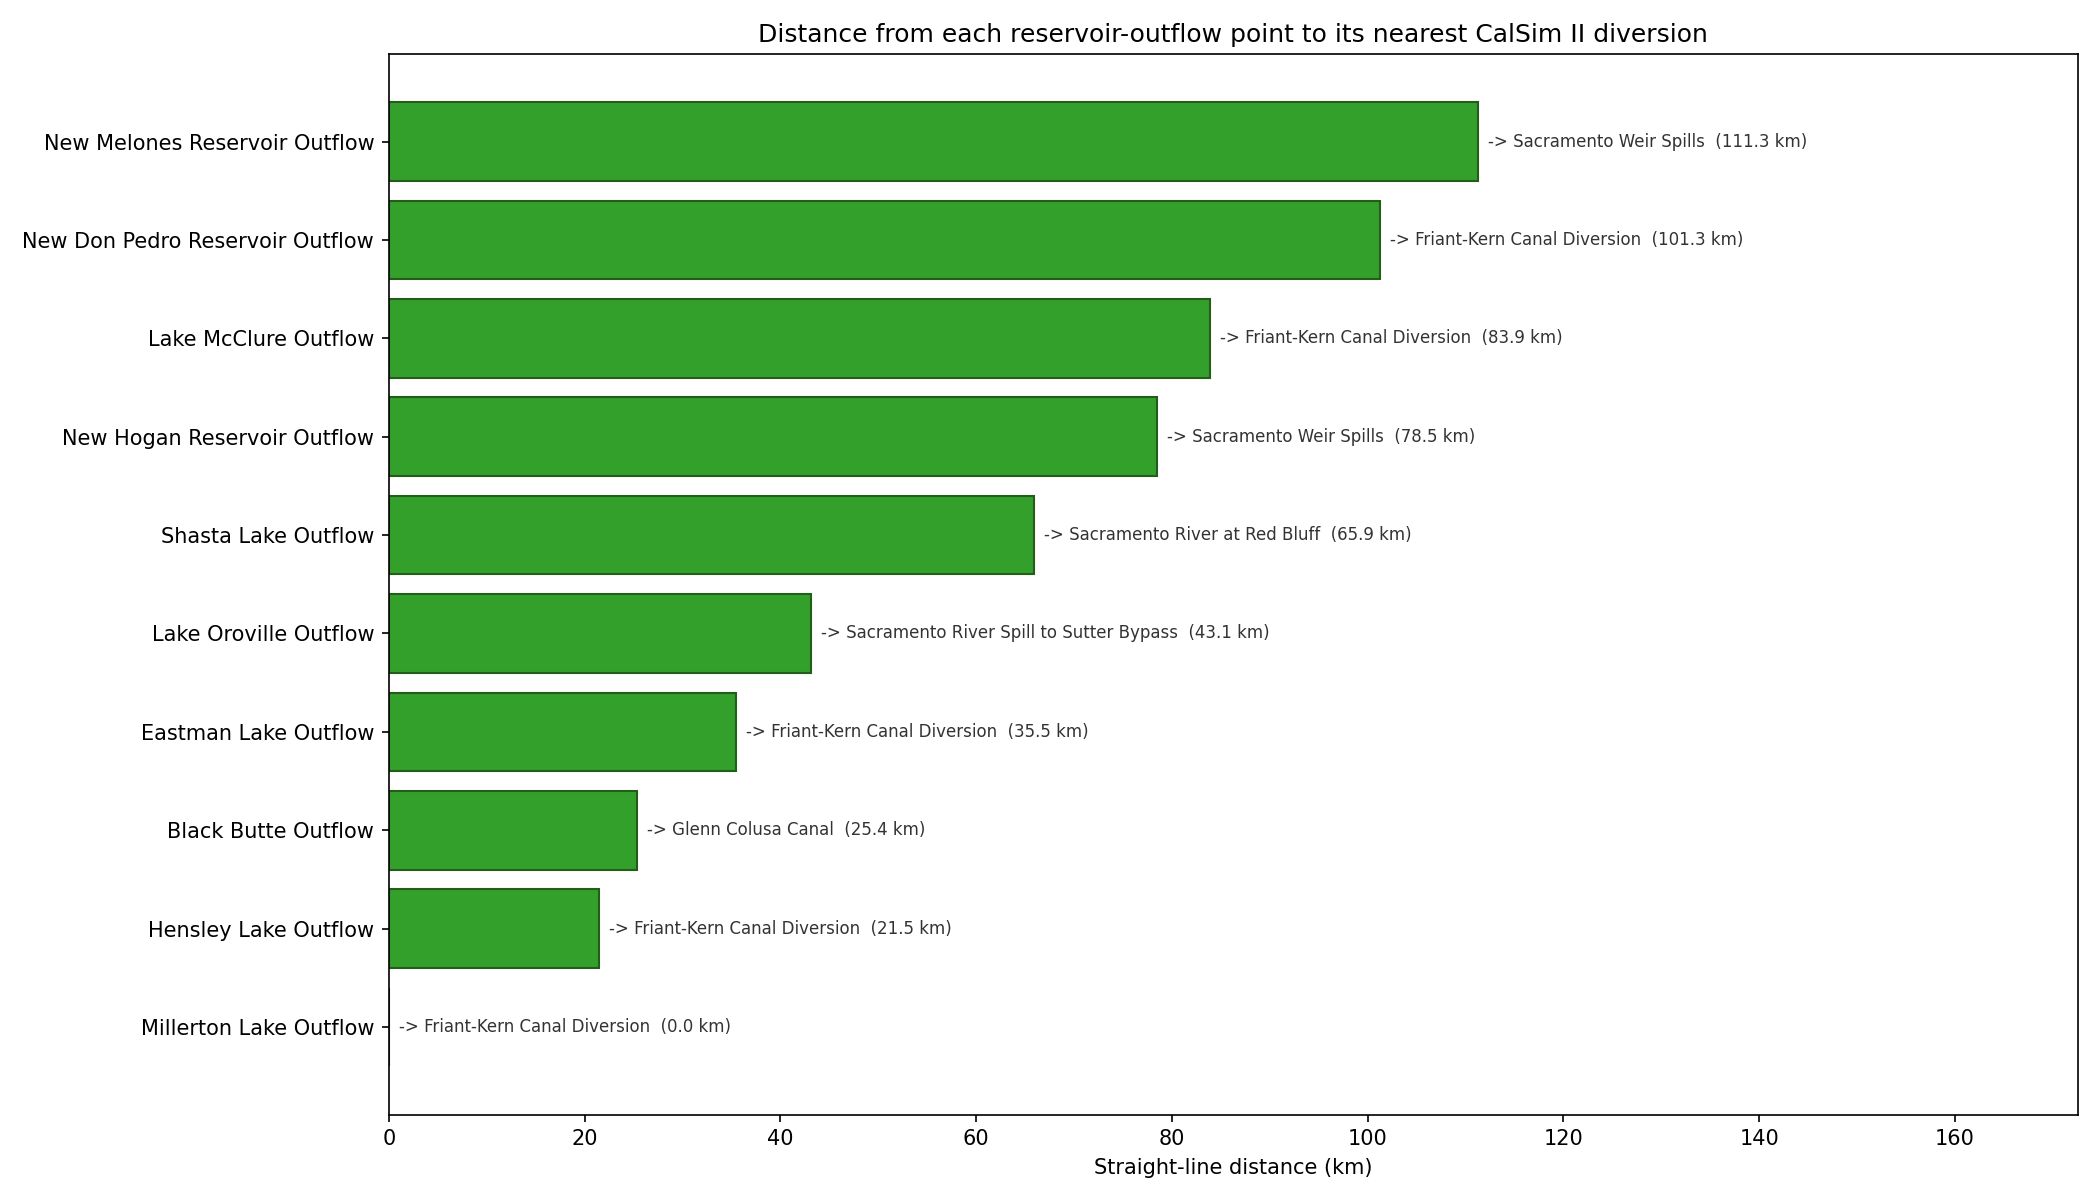

## Are these nearest diversions plausible release destinations?

The straight-line nearest-diversion search is purely geometric — it knows nothing about which way water actually flows. Checking each pairing against Central Valley hydrology, **only about half are hydrologically plausible** . The results split into three groups:

**Genuinely plausible pairings (4)** — the reservoir genuinely releases into the system that feeds the named diversion:
- **Millerton Lake → Friant-Kern Canal (0.0 km):** Co-located at Friant Dam. This is the textbook case — Friant releases *are* what feeds the Friant-Kern Canal. Fully plausible.
- **Hensley Lake → Friant-Kern Canal (21.5 km):** Hensley sits in the San Joaquin-side foothills; while its own releases go into the Fresno River, the Friant-Kern Canal service area is the same federal CVP delivery system on the east side of the valley. Reasonable as a regional destination.
- **Lake Oroville → Sacramento River Spill to Sutter Bypass (43.1 km):** Oroville releases flow down the Feather River to the Sutter Bypass complex. The bypass is a genuine downstream recipient of Oroville's flood releases. Plausible.
- **Black Butte → Glenn Colusa Canal (25.4 km):** Black Butte Dam impounds Stony Creek just west of the Sacramento River; the Glenn-Colusa Canal main intake sits on the Sacramento near Hamilton City. Water released from Black Butte reaches the Sacramento River immediately upstream of the canal. Plausible.

**Hydrologically questionable pairings (3)** — same valley but the geometry skips over a more natural connection:
- **Shasta Lake → Sacramento River at Red Bluff (65.9 km):** Plausible *as a river reach* (Shasta releases do flow past Red Bluff), but the node named "Sacramento River at Red Bluff" here is coded as a *diversion* (CalSim arc D112) rather than a pure channel-flow point — so the pairing flags a diversion structure that draws from Shasta's downstream releases. Directionally correct, semantically loose.
- **New Don Pedro → Friant-Kern Canal (101 km):** Both are on the San Joaquin side, but Don Pedro is on the Tuolumne River near the valley floor; the Friant-Kern Canal is sourced from Friant Dam 100+ km southeast. These are separate CVP vs. Modesto/Turlock Irrigation District systems. **Not a plausible release destination** — it just happens to be the nearest point in a sparse diversion set.
- **Lake McClure → Friant-Kern Canal (83.9 km):** Same issue as Don Pedro. McClure is on the Merced River; Friant-Kern Canal is the Friant system. **Not plausible.**

**Physically implausible pairings (3)** — the diversion is on the *wrong river system* and water cannot reach it without crossing basin divides or flowing uphill:
- **New Melones → Sacramento Weir Spills (111 km):** New Melones is on the Stanislaus River (San Joaquin watershed); the Sacramento Weir is in the Sacramento Valley near the state capital. These are different basins. **Implausible.**
- **New Hogan → Sacramento Weir Spills (78.5 km):** New Hogan is on the Calaveras River (eastern San Joaquin Valley); the Sacramento Weir is again on the wrong side of the Delta. **Implausible.**
- **Eastman Lake → Friant-Kern Canal (35.5 km):** Eastman is on the Chowchilla River; while in the same broad region, its releases don't feed the Friant-Kern Canal system. **Not plausible.**

## Why so many pairings fail the plausibility test

The reason is visible in the dataset itself: **diversions are spatially sparse (only 11 points) and unevenly distributed.** Five of the eleven diversion nodes cluster in the northern Sacramento Valley (the Sutter Bypass / Glenn-Colusa / Sacramento Weir complex), and the Friant-Kern Canal acts as a single geographic anchor for the entire southern San Joaquin Valley. With no diversion node co-located near, say, the Stanislaus or Calaveras rivers, the nearest-neighbor algorithm is forced to snap southern/central reservoirs to whichever of the two diversion clusters is geometrically closer — even when a basin divide makes the connection hydrologically impossible.

**Bottom line:** a nearest-neighbor search is a useful *first-pass* screen — it correctly identifies the co-located Millerton/Friant-Kern pairing and the Oroville/Sutter-Bypass connection — but for roughly half of these reservoirs the straight-line nearest diversion is **not** a physically meaningful release destination, because the CalSim II diversion-node network is too sparse to reflect the true complexity of Central Valley water conveyance.

In [7]:
%%ask
For each of the 10 reservoir-outflow points, which diversion point is
closest, and how many kilometers away? Show the 10 pairings on a map
with lines connecting each reservoir to its nearest diversion. Comment
on whether the closest diversion is a plausible destination for the
reservoir's releases based on Central Valley hydrology.